In [2]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit

In [3]:
def Euler(f_ode, x, y, h):
    return y + h * f_ode(x, y)

def Midpoint(f_ode, x, y, h):
    k1 = h * f_ode(x, y)
    return y + h * f_ode(x + h / 2, y + k1 / 2)

def RK4(f_ode, x, y, h):
    k1 = h * f_ode(x, y)
    k2 = h * f_ode(x + h / 2, y + k1 / 2)
    k3 = h * f_ode(x + h / 2, y + k2 / 2)
    k4 = h * f_ode(x + h, y + k3)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

In [4]:
def CallerGODE(solve_method, f_ode, yinit, xs, h):
    N = len(xs)
    y = np.array(yinit)
    ys = np.zeros((N, len(yinit)), dtype=np.float64)
    for i in range(N):
        x = xs[i]
        ys[i] = y
        y = solve_method(f_ode, x, y, h)
    return ys

In [35]:
def Verlet(f_acc, x, yn, ynm1, h):
    return 2*yn - ynm1 + f_acc(x, yn)*(h**2)


def VelocityVerlet(f_acc, x, yn, vn, h):
    ynp1 = yn + vn * h + 0.5 * f_acc(x, yn, vn) * (h**2)
    vnp1 = vn + 0.5 * (f_acc(x, yn, vn) + f_acc(x + h, ynp1, vn)) * h
    return ynp1, vnp1

def Leapfrog(f_acc, x, yn, vn, h):
    vnph = vn + 0.5 * f_acc(x, yn, vn)*h
    ynp1 = yn + vnph*h
    vnp1 = vnph + 0.5 * f_acc(x + h, ynp1, vn)*h
    return ynp1, vnp1

In [23]:
def CallerVerlet(f_acc, y0, v0, xs, h):
    N = len(xs)
    ys = np.zeros(N)
    ys[0] = y0
    x0 = xs[0]
    ys[1] = y0 + v0 * h + 0.5 * f_acc(x0, y0) * (h**2)
    for i in range(2, N):
        x = xs[i]
        ys[i] = Verlet(f_acc, x, ys[i-1], ys[i-2], h)
    return ys

In [24]:
def CallerVVL(method, f_acc, y0, v0, xs, h):
    N = len(xs)
    ys = np.zeros(N)
    vs = np.zeros(N)
    
    ys[0] = y0
    vs[0] = v0

    for i in range(1, N):
        x = xs[i]
        ys[i], vs[i] = method(f_acc, x, ys[i - 1], vs[i - 1], h)
    return ys, vs

# WS Examples

In [8]:
def linear(x, c, m):
    return c + m * x

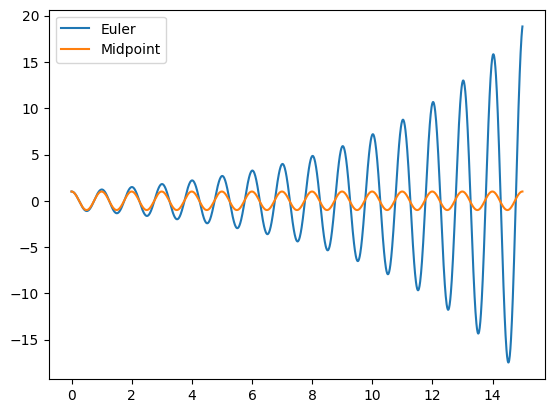

N	h	Euler Error		Midpoint Error
150000	0.0001	0.03005109180448229	1.9059273537180843e-07
84352	0.0002	0.05406334905985921	4.068073766738678e-09
47435	0.0003	0.09815409657949337	5.71289633377603e-08
26675	0.0006	0.18116328804229176	4.0479740781584894e-07
15000	0.0010	0.34451620350574896	1.3113320531221717e-05
8436	0.0018	0.6929511407319477	1.623992586630152e-05
4744	0.0032	1.549334129251072	9.025281074603875e-05
2668	0.0056	4.271250759272563	0.0005082317661699864
[3.20453184 1.19907602]
[2.40300133 2.59922409]


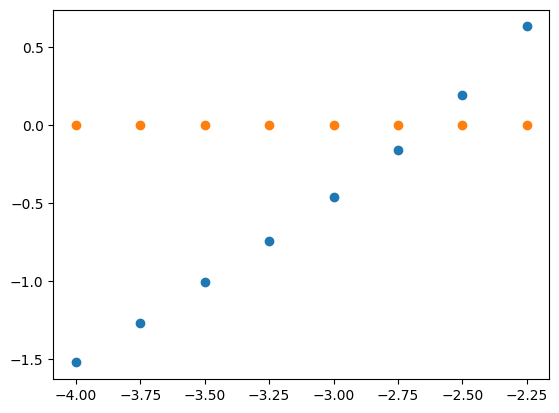

In [9]:
def f_ode(x, y):
    return np.array([y[1], -4 * np.pi * np.pi * y[0]])

h = 0.01
x = np.arange(0.0, 15.0, h)
yinit = [1.0, 0.0]
y_euler = CallerGODE(Euler, f_ode, yinit, x, h)
y_midpoint = CallerGODE(Midpoint, f_ode, yinit, x, h)

plt.plot(x, y_euler[:, 0], label='Euler')
plt.plot(x, y_midpoint[:, 0], label='Midpoint')
plt.legend()
plt.show()

hs = 10**np.arange(-4.0, -2.0, 0.25)
y_eyact = np.cos(np.pi * 2 * 15.0)
print("N\th\tEuler Error\t\tMidpoint Error")
deuler = np.zeros_like(hs)
dmidpoint = np.zeros_like(hs)

for i, h in enumerate(hs):
    xh = np.arange(0.0, 15.0, h)
    y_euler = CallerGODE(Euler, f_ode, yinit, xh, h)[:, 0]
    y_midpoint = CallerGODE(Midpoint, f_ode, yinit, xh, h)[:, 0]
    y_euler_error = np.abs(y_euler[-1] - y_eyact).item()
    y_midpoint_error = np.abs(y_midpoint[-1] - y_eyact).item()
    deuler[i] = y_euler_error
    dmidpoint[i] = y_midpoint_error
    print(f"{len(xh)}\t{h:.4f}\t{y_euler_error}\t{y_midpoint_error}")

logh = np.log10(hs)
logdeuler = np.log10(deuler)
logdmidpoint = np.log10(dmidpoint)


popt_e, _ = curve_fit(linear, logh, logdeuler)
popt_m, _ = curve_fit(linear, logh, logdmidpoint)

print(popt_e)
print(popt_m)

plt.scatter(logh, logdeuler)
plt.scatter(logh, dmidpoint)
plt.show()

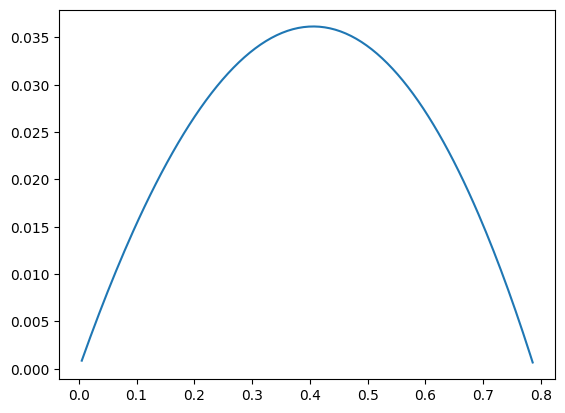

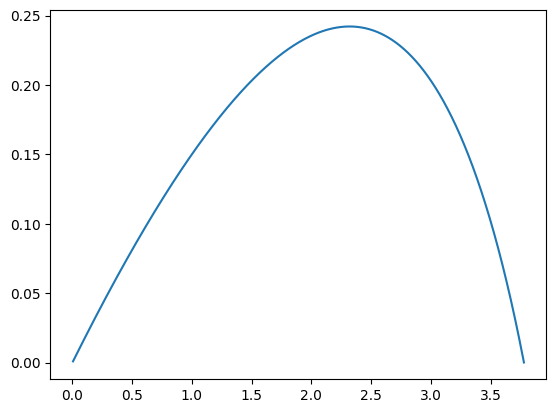

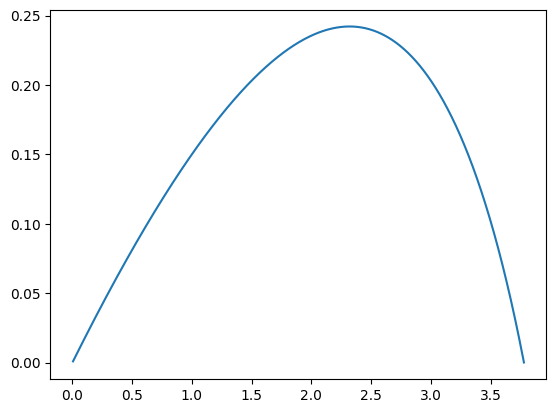

In [37]:
m = 2
v0 = 10
g = 9.8
gamma = 2
theta = np.pi / 3

def f_ode(t, y):
    vx = y[1]
    vy = y[3]
    ax = -(gamma / m) * vx
    ay = -g - (gamma / m) * vy
    return np.array([vx, ax, vy, ay])


h = 0.001
t = np.arange(0.0, 10.0, h)


# RK4
yinit = [0.0, v0 * np.cos(theta), 0.0, np.sin(theta)]
y_rk4 = CallerGODE(RK4, f_ode, yinit, t, h)
y_rk4 = y_rk4[y_rk4[:, 2] > 0]
plt.plot(y_rk4[:, 0], y_rk4[:, 2])
plt.show()

# Velocity Verlet / Leapfrog
def f_acc_x(t, x, vx):
    # ax = -vx
    return -vx

def f_acc_y(t, y, vy):
    # ay = -1 - vy
    return -1.0 - vy

# Velocity Verlet
y_verletx, _ = CallerVVL(VelocityVerlet, f_acc_x, yinit[0], yinit[1], t, h)
y_verlety, _ = CallerVVL(VelocityVerlet, f_acc_y, yinit[2], yinit[3], t, h)
y_verletx = y_verletx[y_verlety > 0]
y_verlety = y_verlety[y_verlety > 0]

plt.plot(y_verletx, y_verlety)
plt.show()

# Leapfrog
y_leapfrogx, _ = CallerVVL(Leapfrog, f_acc_x, yinit[0], yinit[1], t, h)
y_leapfrogy, _ = CallerVVL(Leapfrog, f_acc_y, yinit[2], yinit[3], t, h)
y_leapfrogx = y_leapfrogx[y_leapfrogy > 0]
y_leapfrogy = y_leapfrogy[y_leapfrogy > 0]

plt.plot(y_leapfrogx, y_leapfrogy)
plt.show()
